In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [59]:
data  = sns.load_dataset('mpg')
df = data.copy()
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [60]:
df.shape

(398, 9)

In [61]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

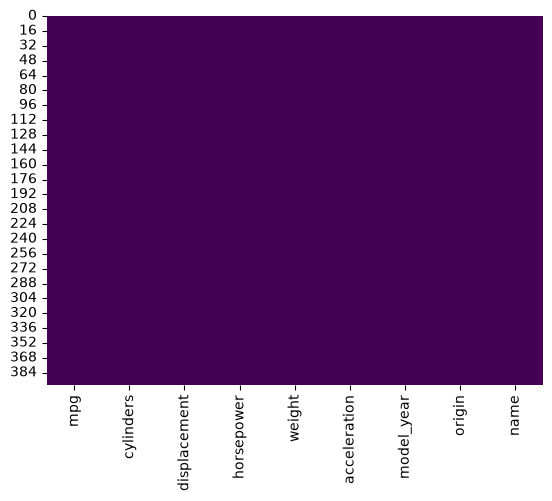

In [62]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

In [63]:
x = df.drop(['origin','name'], axis=1)
y = df['origin']

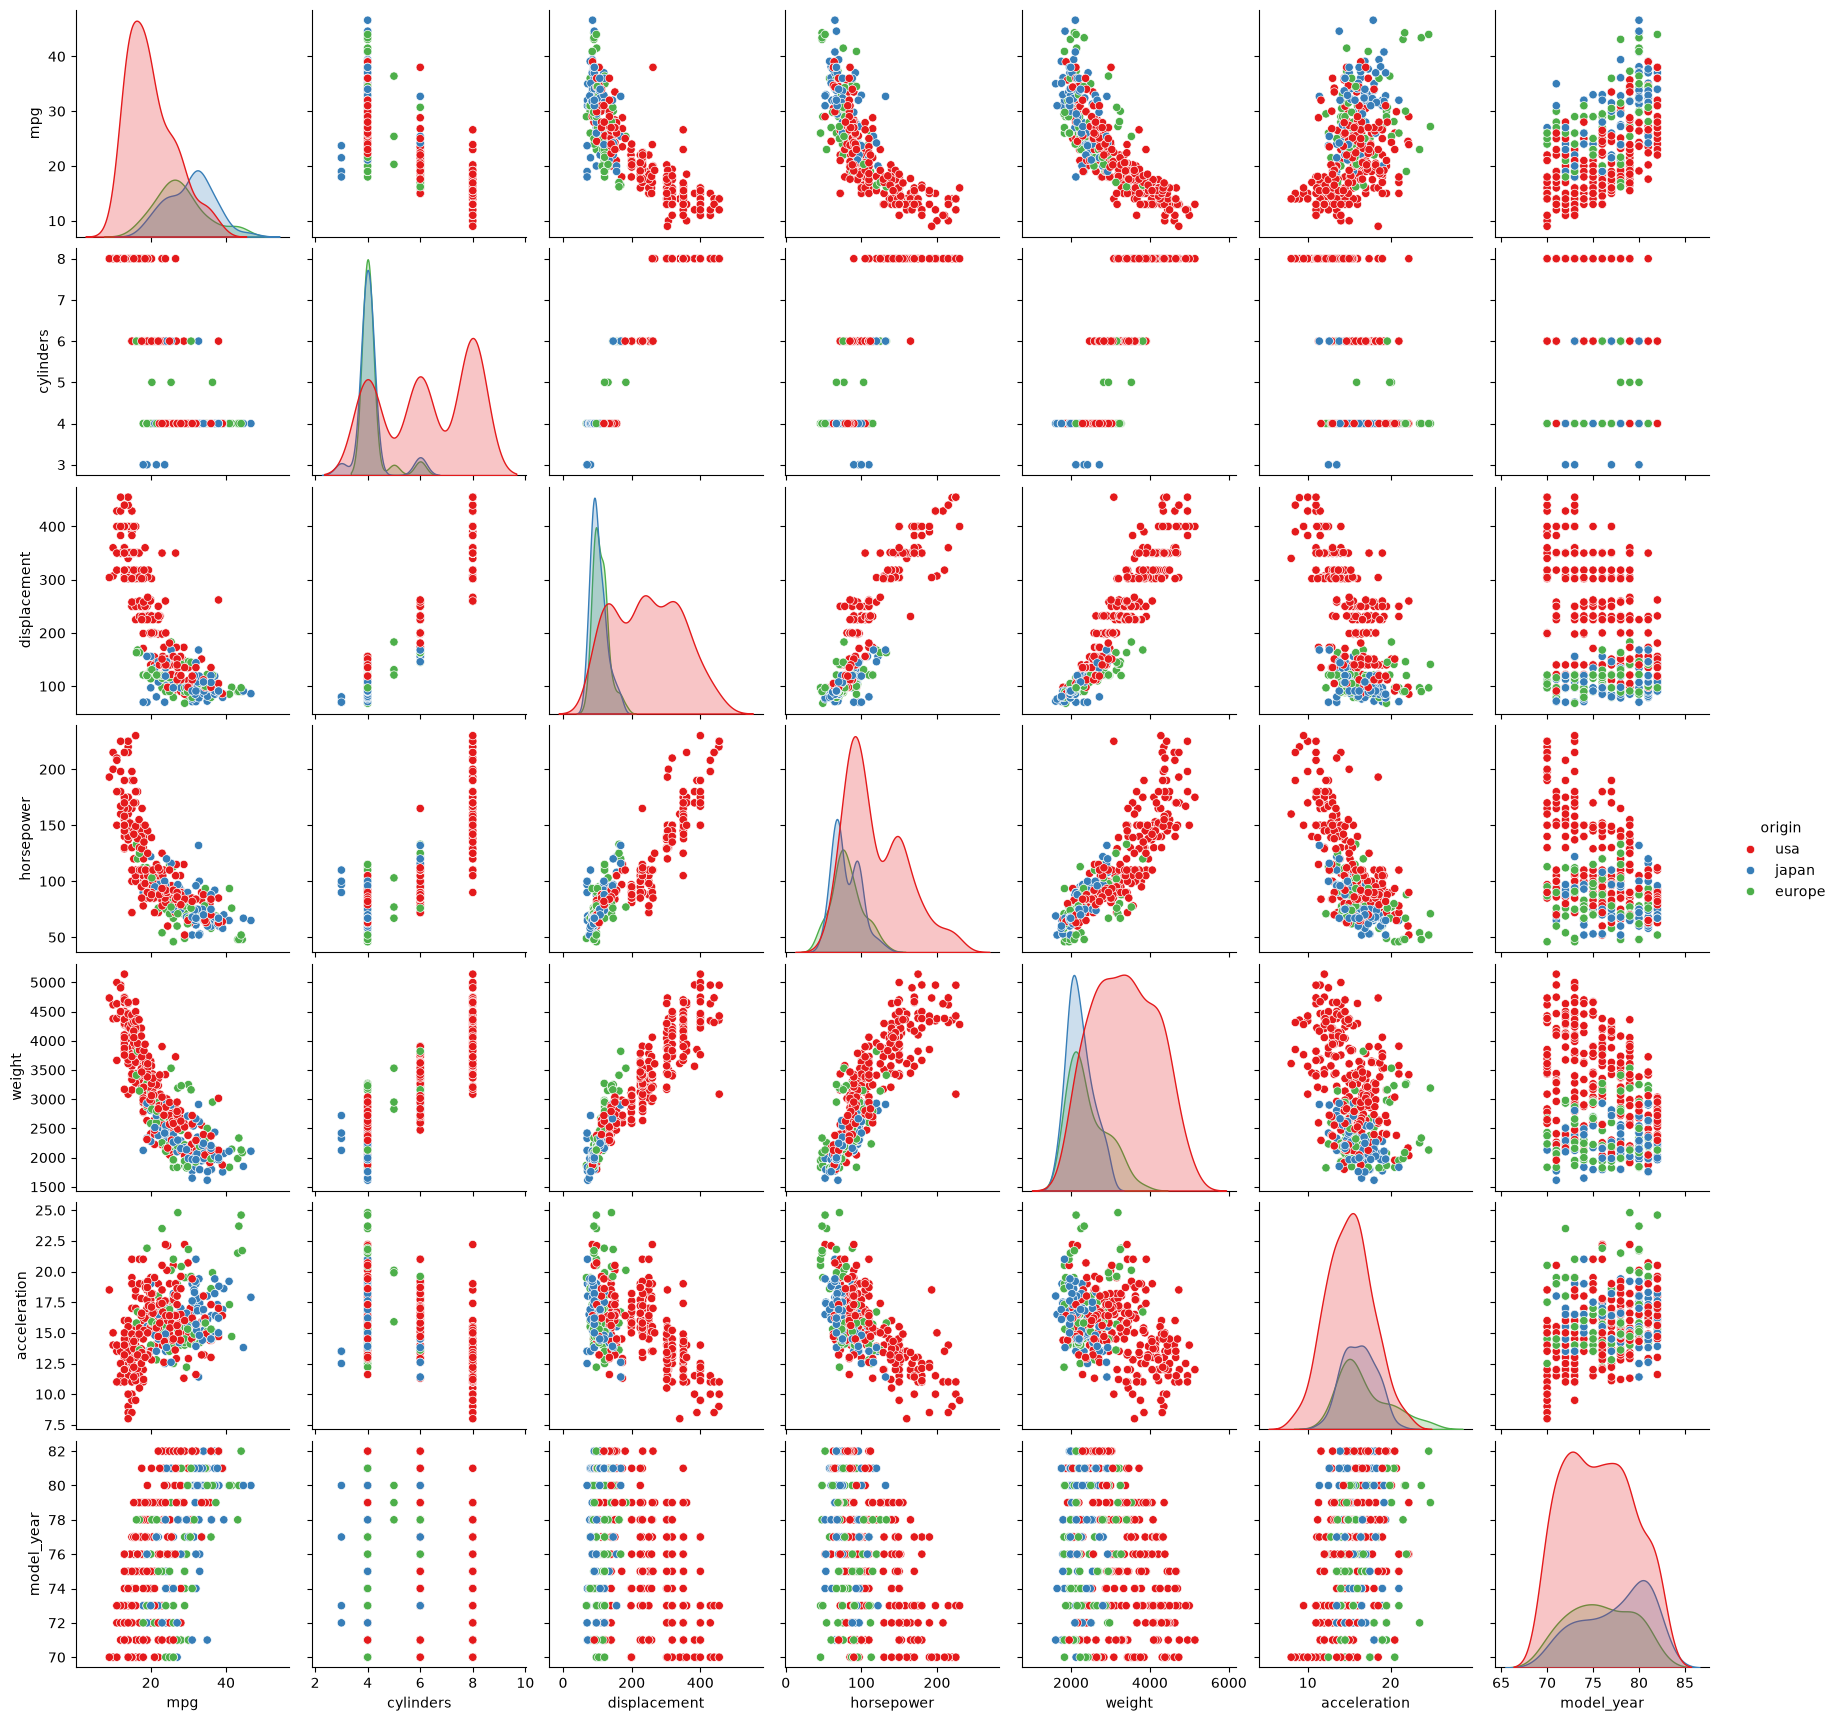

In [64]:
sns.pairplot(df, hue='origin', palette='Set1')
plt.show()

In [65]:
x_scaled = scaler.fit_transform(x)
df_scaled = pd.DataFrame(x_scaled,columns = x.columns)
df_scaled.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426


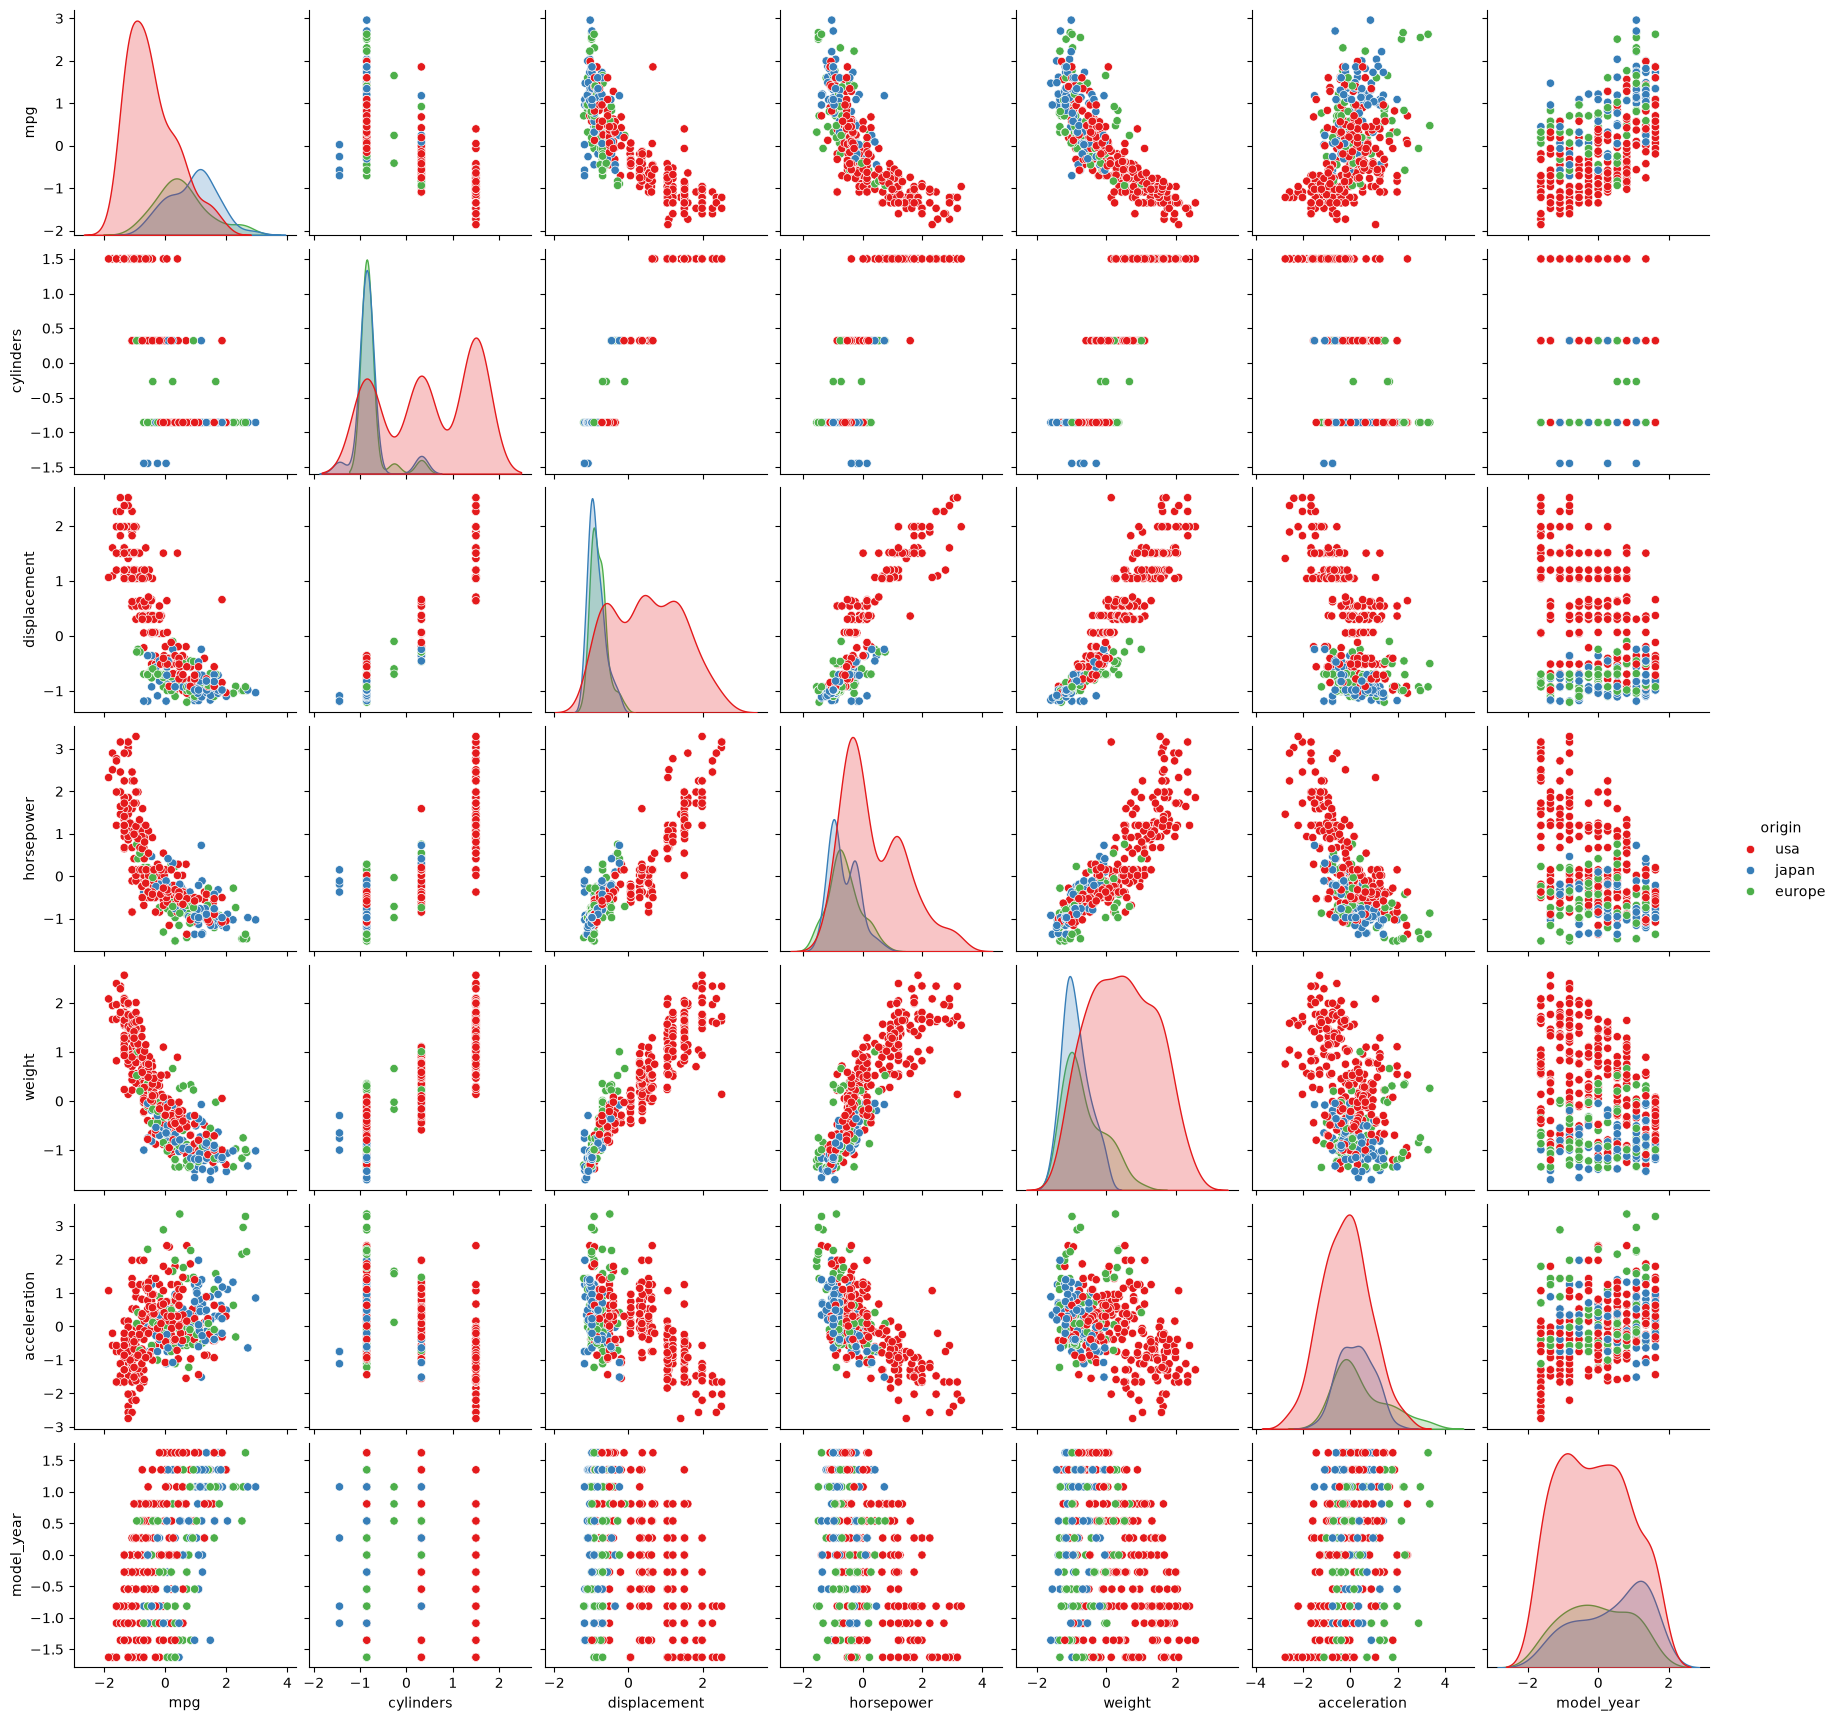

In [66]:
sns.pairplot(df_scaled.assign(origin=y), hue='origin', palette='Set1')
plt.show()

In [67]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=3, random_state=42)
labels = kmean.fit_predict(df_scaled)
df_scaled['kmean_cluster'] = labels
df_scaled.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,kmean_cluster
0,-0.706439,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,1
1,-1.090751,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,1
2,-0.706439,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,1
3,-0.962647,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,1
4,-0.834543,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,1


In [68]:
df_scaled.kmean_cluster.unique()

array([1, 0, 2], dtype=int32)

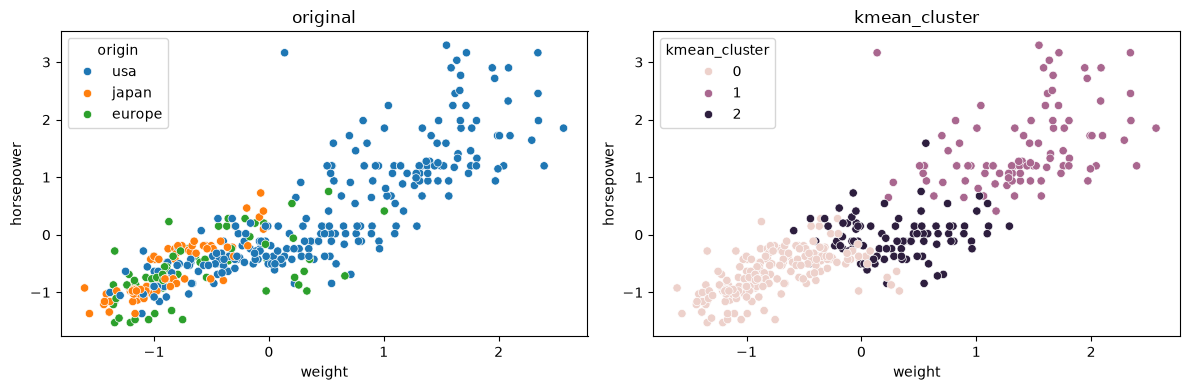

In [69]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.scatterplot(x= 'weight',y='horsepower', hue= y ,data= df_scaled)
plt.title('original')
plt.subplot(1,2,2)
sns.scatterplot(x= 'weight',y= 'horsepower', hue= 'kmean_cluster' ,data= df_scaled)
plt.title('kmean_cluster')
plt.tight_layout()
plt.show()

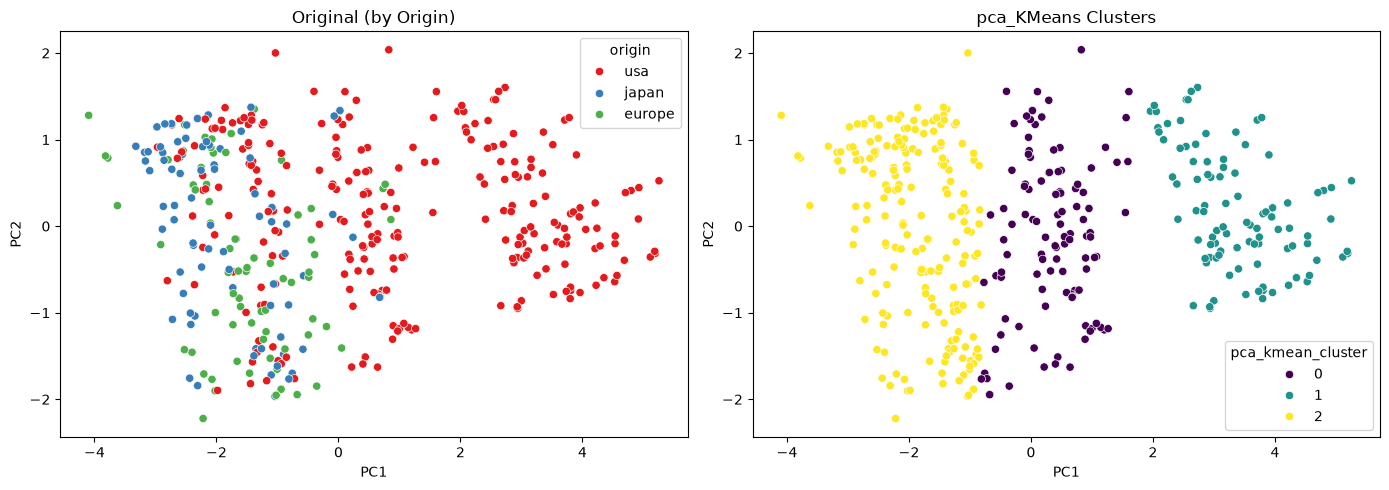

In [70]:
from sklearn.decomposition import PCA

# 1. Sirf numerical features par PCA lagao (kmean_cluster column ko chhod kar)
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[features])

df_scaled_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# 2. Dono ko side-by-side plot karo
plt.figure(figsize=(14, 5))
df_scaled_pca['pca_kmean_cluster'] = kmean.fit_predict(df_scaled_pca)

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue=y, data=df_scaled_pca, palette='Set1')
plt.title('Original (by Origin)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='pca_kmean_cluster', data=df_scaled_pca, palette='viridis')
plt.title('pca_KMeans Clusters')

plt.tight_layout()
plt.show()

In [72]:
df_scaled_pca.head()

,PC1,PC2,pca_kmean_cluster
0,2.661556,-0.918577,1
1,3.523307,-0.789779,1
2,2.998309,-0.861604,1
3,2.937560,-0.949168,1
4,2.930688,-0.931822,1


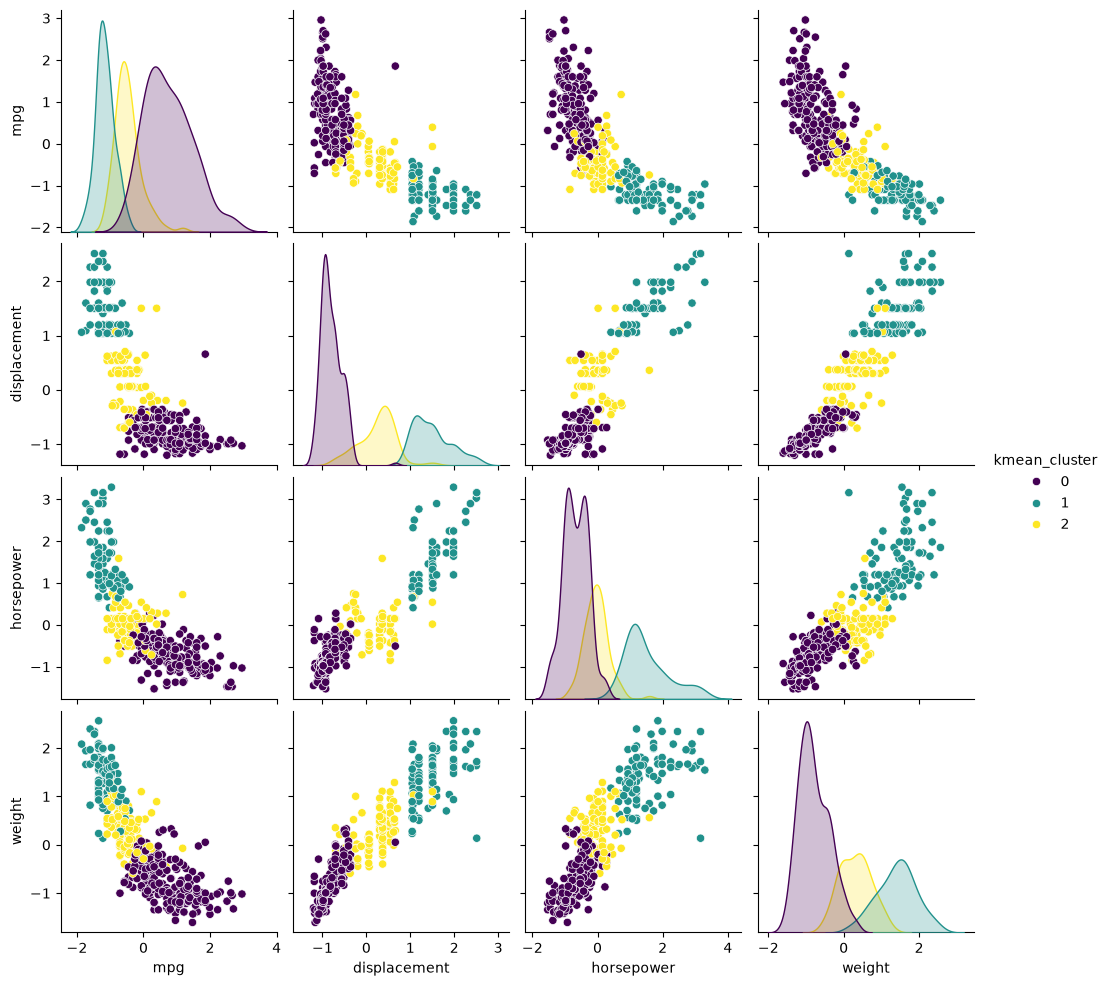

In [75]:
cols_to_plot = ['mpg', 'displacement', 'horsepower', 'weight']

sns.pairplot(df_scaled, vars=cols_to_plot, hue='kmean_cluster', palette='viridis')

plt.show()

In [76]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize
lda = LinearDiscriminantAnalysis(n_components=2)

# Fit & Transform (isme X ke saath y bhi dena zaroori hota hai)
lda_result = lda.fit_transform(df_scaled[features], y)
lda.explained_variance_ratio_

array([0.94799932, 0.05200068])

In [79]:
lda_result_df = pd.DataFrame(lda_result, columns=['LD1', 'LD2'])
lda_result_df['lda_kmean_cluster'] = kmean.fit_predict(lda_result_df)
lda_result_df.head()

,LD1,LD2,lda_kmean_cluster
0,0.969093,0.056504,1
1,1.407234,-0.572202,1
2,0.792744,-0.642556,1
3,0.694956,-0.482039,1
4,0.736050,-0.278309,1


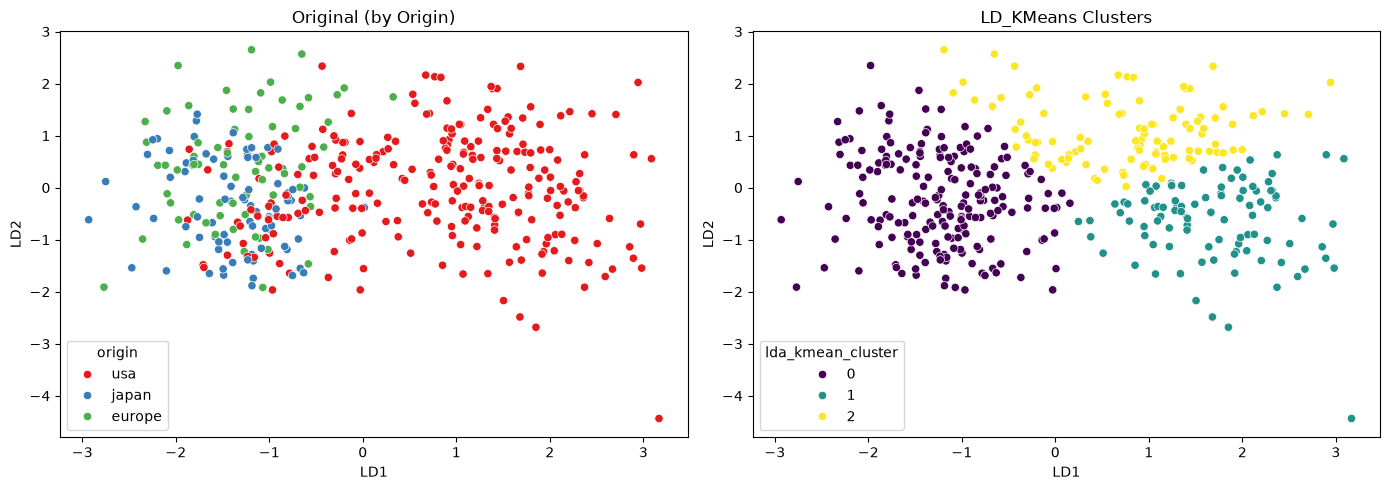

In [81]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='LD1', y='LD2', hue=y, data=lda_result_df, palette='Set1')
plt.title('Original (by Origin)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='LD1', y='LD2', hue='lda_kmean_cluster', data=lda_result_df, palette='viridis')
plt.title('LD_KMeans Clusters')

plt.tight_layout()
plt.show()